<p><h1>Importing Python Modules</h1></p>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

<h2>Reading Dataset and Loading Only Required Columns</h2>

In [2]:
# Load only the columns needed for the problem statement
required_cols = [
    'number_inpatient',       # Prior visits
    'number_emergency',       # Prior visits
    'number_outpatient',      # Prior visits
    'num_lab_procedures',     # Vitals/Clinical tests
    'num_medications',        # Treatment complexity
    'time_in_hospital',       # Severity indicator
    'number_diagnoses',       # Diagnosis count
    'readmitted'              # Target column
]
df = pd.read_csv('diabetic_data.csv', usecols = required_cols)

print("Dataset shape: ", df.shape)
df.head()

Dataset shape:  (101766, 8)


,time_in_hospital,num_lab_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted
0,1,41,1,0,0,0,1,NO
1,3,59,18,0,0,0,9,>30
2,2,11,13,2,0,1,6,NO
3,2,44,16,0,0,0,7,NO
4,1,51,8,0,0,0,5,NO


<h2>Target Encoding and Data Check</h2>

In [3]:
# Convert target to binary: 1 if readmitted < 30 days, 0 otherwise
df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)

# Drop original text target column
df.drop(columns=['readmitted'], inplace=True)

# Check missing values and class distribution
print("Missing values per column:\n", df.isnull().sum())
print("\nClass Distribution (0 = Not Readmitted < 30d, 1 = Readmitted < 30d:")
print(df['readmitted_30d'].value_counts())
print("\nClass Ratio:\n", df['readmitted_30d'].value_counts(normalize=True))

Missing values per column:
 time_in_hospital      0
num_lab_procedures    0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0
readmitted_30d        0
dtype: int64

Class Distribution (0 = Not Readmitted < 30d, 1 = Readmitted < 30d:
readmitted_30d
0    90409
1    11357
Name: count, dtype: int64

Class Ratio:
 readmitted_30d
0    0.888401
1    0.111599
Name: proportion, dtype: float64


<h2>Train-Test Split and Feature Scaling</h2>

In [4]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop(columns=['readmitted_30d'])
y = df['readmitted_30d']

# Split 80% train, 20% test (stratify ensures class balance is maintained)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize features (mean=0, variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])

Training samples: 81412
Testing samples: 20354


<h2>Train Logistic Regression with L2 Regularization</h2>

In [5]:
# Initialize Logistic Regression with L2 penalty
log_reg = LogisticRegression(
    penalty='l2', 
    C=1.0, 
    solver='lbfgs', 
    class_weight='balanced',  # Handles class imbalance
    max_iter=1000, 
    random_state=42
)

# Fit model
log_reg.fit(X_train_scaled, y_train)

# Inspect learned feature weights
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Learned Feature Importance (Coefficients):")
print(feature_importance)

Learned Feature Importance (Coefficients):
              Feature  Coefficient
5    number_inpatient     0.372348
6    number_diagnoses     0.101012
0    time_in_hospital     0.082499
4    number_emergency     0.050587
2     num_medications     0.037345
1  num_lab_procedures     0.002076
3   number_outpatient    -0.004245


D:\Developer_Caches\micromamba\envs\aiml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


<h2>Evaluation with ROC-AUC amd Plot ROC Curve</h2>

Test ROC-AUC Score: 0.6341

Confusion Matrix:
[[12834  5249]
 [ 1192  1079]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.71      0.80     18083
           1       0.17      0.48      0.25      2271

    accuracy                           0.68     20354
   macro avg       0.54      0.59      0.53     20354
weighted avg       0.83      0.68      0.74     20354



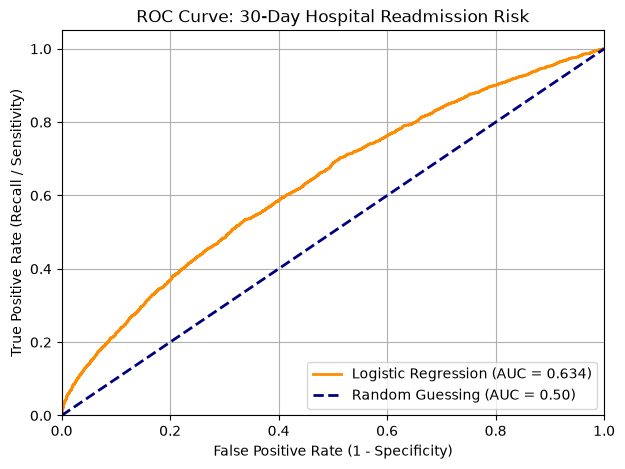

In [6]:
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, classification_report)

# Predict probabilities for the positive class (readmission within 30 days)
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred = log_reg.predict(X_test_scaled)

# Calculate ROC-AUC Score
auc_score = roc_auc_score(y_test, y_probs)
print(f"=====================================")
print(f"Test ROC-AUC Score: {auc_score:.4f}")
print(f"=====================================\n")

# Confusion Matrix and Metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.title('ROC Curve: 30-Day Hospital Readmission Risk')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()